# Fig: Distribution of last Pmax in Infotaxis vs MAP comparison: pmax_th=0.95

Reference: 
- `20260531_fig_infotaxis_MAP_cmp_pmax0.95.ipynb`

In [1]:
from pathlib import Path

import pandas as pd

import seaborn as sns

In [2]:
from plot_utils import bar_violinplot_last_pmax
from simulation_data_prep import get_success_fname

In [3]:
# Set path
path_data = Path("/Volumes/ssd_2tb_1/infotaxis_simu_2026")

path_fig = Path("../figs_paper_2026")

Samples: left:  989    right:  514
Mean:    left: 0.987  right: 0.658
Median:  left: 0.988  right: 0.500

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  991    right:  545
Mean:    left: 0.981  right: 0.623
Median:  left: 0.985  right: 0.497

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  971    right:  534
Mean:    left: 0.972  right: 0.611
Median:  left: 0.973  right: 0.495

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  976    right:  501
Mean:    left: 0.967  right: 0.562
Median:  left: 0.967  right: 0.487

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------


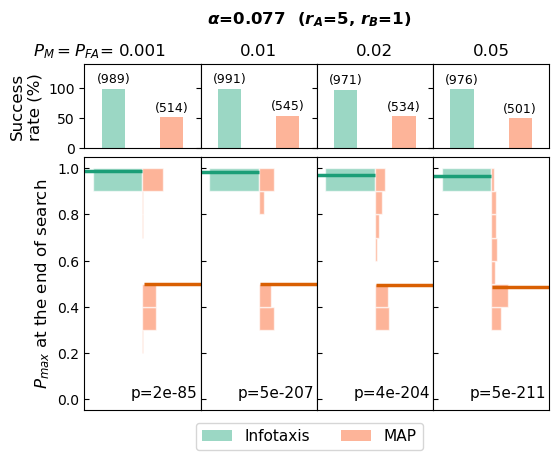

Samples: left:  977    right:  339
Mean:    left: 0.980  right: 0.526
Median:  left: 0.981  right: 0.485

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  974    right:  303
Mean:    left: 0.971  right: 0.459
Median:  left: 0.972  right: 0.416

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  969    right:  300
Mean:    left: 0.967  right: 0.402
Median:  left: 0.967  right: 0.343

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  959    right:  298
Mean:    left: 0.960  right: 0.371
Median:  left: 0.958  right: 0.317

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------


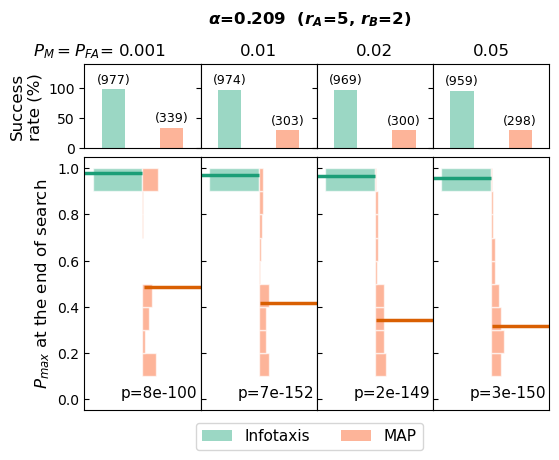

Samples: left:  986    right:  524
Mean:    left: 0.983  right: 0.658
Median:  left: 0.985  right: 0.500

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  985    right:  535
Mean:    left: 0.983  right: 0.636
Median:  left: 0.987  right: 0.497

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  968    right:  520
Mean:    left: 0.973  right: 0.635
Median:  left: 0.975  right: 0.643

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  967    right:  510
Mean:    left: 0.968  right: 0.566
Median:  left: 0.969  right: 0.490

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------


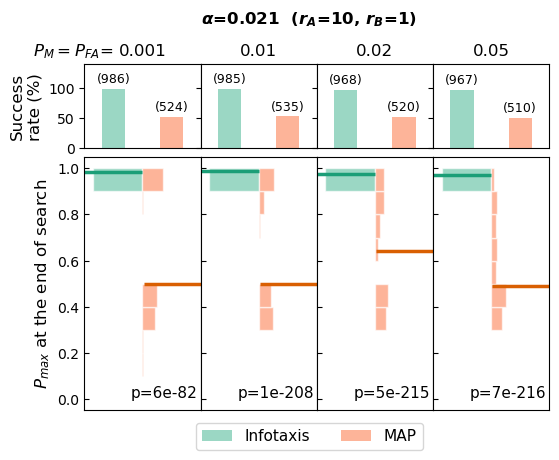

Samples: left:  980    right:  313
Mean:    left: 0.979  right: 0.512
Median:  left: 0.979  right: 0.472

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  966    right:  332
Mean:    left: 0.970  right: 0.469
Median:  left: 0.972  right: 0.395

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  968    right:  306
Mean:    left: 0.965  right: 0.399
Median:  left: 0.965  right: 0.323

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------
Samples: left:  961    right:  244
Mean:    left: 0.958  right: 0.359
Median:  left: 0.957  right: 0.311

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------


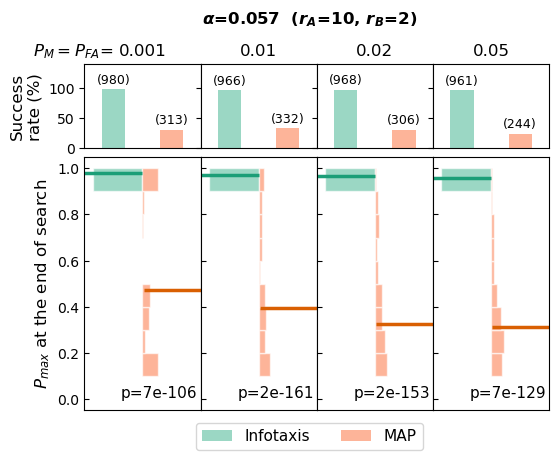

In [4]:
cr_all = [5, 10]
br_all = [1, 2]
pm_all = [0.001, 0.01, 0.02, 0.05]

for cr in cr_all:
    for br in br_all:

        path_left = path_data / "20260530_infotaxis_match_summary_compiled_pmax095_pmaxDiff1e-5"
        path_right = path_data / "20260530_MAP_match_summary_compiled_pmax095_pmaxDiff1e-5"
        pmax_th = 0.95
        pmax_diff_th = 1e-5

        df_x_all = []
        df_y_all = []
        for pm in pm_all:
            # Load summary and ph details
            df_x = pd.read_csv(
                path_left / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="simple",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm
                ), index_col=0
            )
            df_y = pd.read_csv(
                path_right / get_success_fname(
                    search_type="MAP", cr=cr, br=br, simulation_type="simple",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm
                ), index_col=0
            )
            df_x_all.append(df_x)
            df_y_all.append(df_y)

        
        fig = bar_violinplot_last_pmax(
            cr=cr, br=br, pm_all=pm_all,
            df_x_all=df_x_all, df_y_all=df_y_all,
            x_str="Infotaxis", y_str="MAP",
            comparison_type="simple",
            stats_type="two-sided",
            colors=sns.color_palette("Set2"),
            colors_dark=sns.color_palette("Dark2"),
            bar_step=0.1,
            color_idx_left=0, color_idx_right=1,
            alpha=0.65
        )

        fig.savefig(
            path_fig / f"fig_last_pmax_infotaxis_MAP_cmp_cr{cr}_br{br}_pmaxTh0.95_pmaxDiff1e-5.png",
            dpi=300, bbox_inches="tight"
        )